ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [2]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

_Write your calculations and explanation here. You may use Python below if you want, but final reasoning must be readable._

Q1.1

In [ ]:
from scipy.sparse import data
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
df = pd.DataFrame(data_q1)
median= df[0].median()
q1=df[0].quantile(0.25)
q3=df[0].quantile(0.75)
IQR=q3-q1

print(f"The median: {median}\nThe IQR: {IQR}")

The median: 33.0
The IQR: 2.0


Q1.2

In [ ]:
lower_range=q1-1.5*IQR
upper_range=q3+1.5*IQR
print(f"Upper fence: {upper_range}, Lower fence: {lower_range}")
outliers= [x for x in df[0] if x < lower_range or x > upper_range ]
is_outlier = 'YES' if 500 in outliers else 'NO'
print("Is 500 an outlier?",is_outlier)

Upper fence: 37.0, Lower fence: 29.0
Is 500 an outlier? YES


Q1.3

In [ ]:
mean=df[0].mean()
sd=df[0].std()

print(f"Mean: {mean}, Standard Dviation: {sd:.2f}")

Mean: 79.4, Standard Dviation: 147.79


The median (33) and IQR (2) are robust measures that resist the influence of extreme values. The outlier 500 changes the mean to 79.4 and standard deviation to 140.8, which misrepresent the typical customer spending pattern. In contrast, the median accurately represents that most customers spend around $30-35, and the small IQR shows tight clustering for the majority. For skewed distributions with outliers, median and IQR provide a more truthful representation of central tendency and variability.

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

_Write your step by step Bayes calculation and explanation here._

Q2.1

From the question, we have to find the probability of someone has the disease given that they tested positive P(Disease|Positive).

Now, P(Disease|Positive) = P(Positive and Disease) / P(Positive)\
or, P(Disease|Positive) = {P(Positive|Disease)*P(Disease)}/P(Positive)\
Now we know, P(Positive|Disease) means the probability of positive prediction such that all have the disease, that means sensitivity. And P(Positive) is the disease reate or pervelence.

or, P(Disease|Positive) = (Sensitivity * Pervelence)/P(Positive)....(1)

Again, P(Positive) = All positive prediction = True Positive + False positive\
or, P(Positive)= P(Positive|Disease)*P(Disease) + P(Positive|No disease)*P(No Disease)....(2)

From eq. (1) & (2),\
P(Disease|Positive) = (Sensitivity * Pervelence) / {P(Positive|Disease)*P(Disease) + P(Positive|No disease)*P(No Disease)}

No disease = 1 - Pervenlence\
P(Positive|No disease) means probability of tested positive such that the do not have the disease, that means 1 - specificity.

In [ ]:
disease_rate = 0.01
sensitivity = 0.90
specificity = 0.92

no_disease =1 -disease_rate
false_positive= 1 - specificity

positive = (sensitivity * disease_rate) + (false_positive * no_disease)
positive_predict = (sensitivity * disease_rate) / positive
print(f"Positive Predictive Value (PPV): {positive_predict*100:.2f}%")

Positive Predictive Value (PPV): 10.20%


Q2.2

In [ ]:
disease_new_rate = 0.20
no_disease_new = 1 - disease_new_rate

positive_new = (sensitivity * disease_new_rate) + (false_positive * no_disease_new)
positive_predict_new = (sensitivity * disease_new_rate) / positive_new
print(f"New Positive Predictive Value (PPV): {positive_predict_new*100:.2f}%")

New Positive Predictive Value (PPV): 73.77%


When prevalence rises from 1% to 20%, the PPV increases significantly (from 10.28% to 73.77%). According to Bayes' theorem, PPV equals the probability of true positives divided by all positive tests. When prevalence is higher, true positives increase more than false positives because a larger fraction of the population actually has the disease. This means that among all positive test results, a much higher proportion are genuine cases rather than false alarms, making the test more reliable at higher prevalence rates.

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_Write your task type, preprocessing list, and pipeline paragraph here._

Q3.1

This is a binary classification task because the target variable 'premium_user'
has two discrete classes either 0 or 1.

Q3.2

Preprocessing Steps:
- Handle missing values using imputation (mean/median for numeric, mode for categorical)
- Encode categorical variable using one-hot encoding or label encoding
- Scale/normalize numeric features (age, daily_clicks) using StandardScaler or RobustScaler
- Check for and handle outliers in numeric features, especially in daily_clicks

Q3.3

First, I would load the raw data and perform exploratory data analysis (EDA) to understand distributions, check for missing values, and identify outliers.In the preprocessing phase, I would encode the categorical 'region' variable using one-hot encoding, and scale numeric features using RobustScaler to handle potential outliers. Next, I would split the data into training and test sets (like 80-20 split) to ensure unbiased evaluation. Then, I would train multiple classification models (Logistic Regression, Decision Tree, Random Forest) on the training set and use cross-validation to tune hyperparameters. After training, I would evaluate model performance on the test set using metrics like accuracy, precision, recall, F1-score, and ROC-AUC to select the best model. Finally, I would analyze feature importance to understand which variables drive premium user conversion and deploy the model for predictions.

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [26]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

Q4.1


Missing Values Summary:
age             2
region          0
purchases       1
premium_user    0
dtype: int64

Unique Values per Column:
age             5
region          4
purchases       6
premium_user    2
dtype: int64
                   age  purchases  premium_user
age           1.000000   0.923677      0.789534
purchases     0.923677   1.000000      0.825860
premium_user  0.789534   0.825860      1.000000


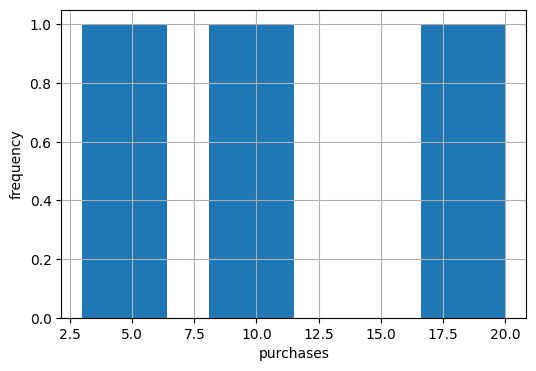

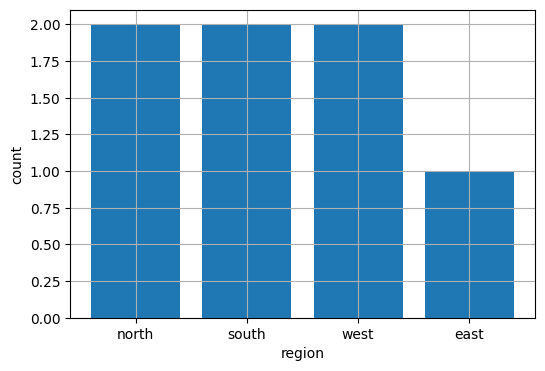

In [27]:
print("\nMissing Values Summary:")
missing_summary = df.isnull().sum()
print(missing_summary)


print("\nUnique Values per Column:")
unique_summary = df.nunique()
print(unique_summary)


numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
print(correlation)

plt.hist(df["purchases"])
plt.xlabel("purchases")
plt.ylabel("frequency")
plt.show()

region_counts = df["region"].value_counts()
plt.bar(region_counts.index, region_counts.values)
plt.xlabel("region")
plt.ylabel("count")
plt.show()

- df.isna().sum() to count how many entries are missing in each column.

- df.nunique() reveals the distinct values in every column.

- df.corr() is used to examine linear relationships among numeric fields.

- histogram shows the distribution of purchases, while a bar chart shows how often each region appears.

Q4.2

In [28]:
age_median = df['age'].median()
df['age'].fillna(age_median)
print(f"\nImputed 'age' with median: {age_median}")

purchases_mean = df['purchases'].mean()
df['purchases'].fillna(purchases_mean)
print(f"Imputed 'purchases' with mean: {purchases_mean:.2f}")

df = pd.get_dummies(df, columns=['region'], prefix='region', dtype=int)

print("\nDataset after imputation and encoding:")
print(df)

numeric_features = ['age', 'purchases']
scaler = RobustScaler()

df[numeric_features] = scaler.fit_transform(df[numeric_features])

print("\nDataset after scaling:")
print(df)


Imputed 'age' with median: 30.0
Imputed 'purchases' with mean: 10.83

Dataset after imputation and encoding:
    age  purchases  premium_user  region_east  region_north  region_south  \
0  25.0        3.0             0            0             1             0   
1  30.0       10.0             1            0             0             1   
2   NaN        5.0             0            0             1             0   
3  22.0        NaN             0            1             0             0   
4  45.0       20.0             1            0             0             0   
5  52.0       18.0             1            0             0             0   
6   NaN        9.0             0            0             0             1   

   region_west  
0            0  
1            0  
2            0  
3            0  
4            1  
5            1  
6            0  

Dataset after scaling:
    age  purchases  premium_user  region_east  region_north  region_south  \
0 -0.25      -0.65             0    

- median imputation fills missing ages, and mean imputation fills missing purchases.

- categorical region becomes multiple binary columns so the model can read it without treating it as numeric by one hot encoding.

- RobustScaler reduces the impact of outliers by scaling based on medians and IQR instead of means.

Q4.3

In [29]:
purchase_threshold = df['purchases'].median()
df['high_spender'] = (df['purchases'] > purchase_threshold).astype(int)

print(f"\nCreated 'high_spender' feature (1 if purchases > {purchase_threshold}, else 0)")
print(f"High spenders: {df['high_spender'].sum()} out of {len(df)}")


Created 'high_spender' feature (1 if purchases > 0.0, else 0)
High spenders: 3 out of 7


Here the median of feature `high_spener` column work as threshold

Q4.4

In [30]:
X = df.drop('premium_user', axis=1)
y = df['premium_user']

print("\nFeature Matrix (X):")
print(X)
print(f"\nShape: {X.shape}")
print(f"Columns: {X.columns.tolist()}")

print("\nTarget Variable (y):")
print(y.values)
print(f"Shape: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")


Feature Matrix (X):
    age  purchases  region_east  region_north  region_south  region_west  \
0 -0.25      -0.65            0             1             0            0   
1  0.00       0.05            0             0             1            0   
2   NaN      -0.45            0             1             0            0   
3 -0.40        NaN            1             0             0            0   
4  0.75       1.05            0             0             0            1   
5  1.10       0.85            0             0             0            1   
6   NaN      -0.05            0             0             1            0   

   high_spender  
0             0  
1             1  
2             0  
3             0  
4             1  
5             1  
6             0  

Shape: (7, 7)
Columns: ['age', 'purchases', 'region_east', 'region_north', 'region_south', 'region_west', 'high_spender']

Target Variable (y):
[0 1 0 0 1 1 0]
Shape: (7,)
Class distribution: {0: 4, 1: 3}


After imputation, encoding, and scaling, all intermediate pieces are combined into one clean dataframe that's fully numeric and ready for training.

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [13]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

Q5.1

In [14]:
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


Build a small pandas dataframe with area, bedroom count, and price so we have a clean supervised regression dataset.

Q5.2

In [16]:
X = df2[['area_sqft', 'bedrooms']]
y = df2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Use train_test_split with an 80/20 ratio to separate the data, ensuring the model is evaluated on unseen examples.

Q5.3

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Feed the training inputs (area_sqft, bedrooms) and target (price) into LinearRegression so it can learn the best-fit line in multiple dimensions.

Q5.4

In [20]:
print("Model Intercept:", model.intercept_)
print("Model Coefficients:", model.coef_)
print("Feature names:", X.columns.tolist())

y_pred = model.predict(X_test)
print("\nTest Set Predictions:")
print("Actual:", y_test.values)
print("Predicted:", y_pred)

Model Intercept: -33.84615384615387
Model Coefficients: [0.15384615 5.38461538]
Feature names: ['area_sqft', 'bedrooms']

Test Set Predictions:
Actual: [120 150]
Predicted: [100.         130.76923077]


Show the learned intercept and feature weights to understand how each predictor influences price.

Generate test-set predictions to see how well the model generalizes.

Q5.5

In [21]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


Mean Absolute Error (MAE): 19.62
Root Mean Squared Error (RMSE): 19.62
R2 Score: -0.7107


- mean_absolute_error reports the average absolute error.

- squrt(mean_squared_error) gives the larger mistakes more heavily.

- r2_score shows how much variance in price the model explains.

Q5.6

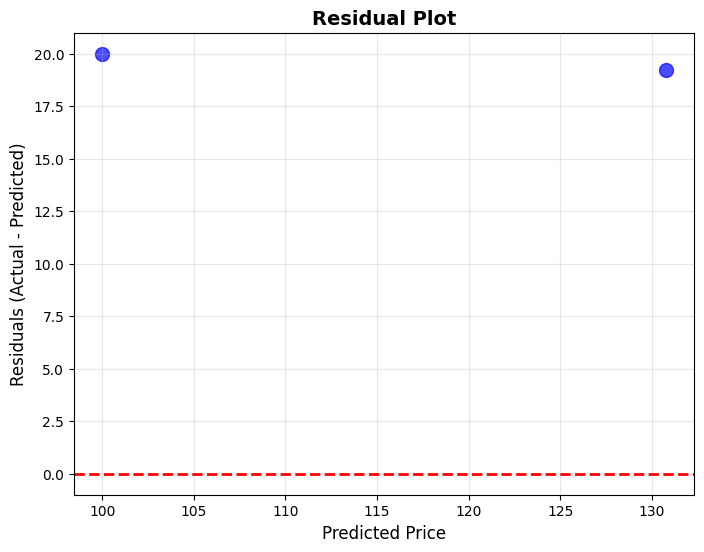

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='blue', alpha=0.7, s=100)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

The residuals show random scatter around zero with no clear pattern. Indicating that the linear regression model is appropriate for this data.

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [31]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._

Q6.1

In [32]:
threshold_1 = 0.5
y_pred_1 = (y_prob >= threshold_1).astype(int)

cm_1 = confusion_matrix(y_true, y_pred_1)
precision_1 = precision_score(y_true, y_pred_1)
recall_1 = recall_score(y_true, y_pred_1)
f1_1 = f1_score(y_true, y_pred_1)

print(f"\nThreshold = {threshold_1}")
print(f"Predictions: {y_pred_1}")
print(f"\nConfusion Matrix:\n{cm_1}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall: {recall_1:.4f}")
print(f"F1 Score: {f1_1:.4f}")


Threshold = 0.5
Predictions: [1 0 1 0 1 0 1 0 1 0]

Confusion Matrix:
[[5 0]
 [0 5]]
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


Q6.2

In [33]:
threshold_2 = 0.3
y_pred_2 = (y_prob >= threshold_2).astype(int)

cm_2 = confusion_matrix(y_true, y_pred_2)
precision_2 = precision_score(y_true, y_pred_2)
recall_2 = recall_score(y_true, y_pred_2)
f1_2 = f1_score(y_true, y_pred_2)

print(f"\nThreshold = {threshold_2}")
print(f"Predictions: {y_pred_2}")
print(f"\nConfusion Matrix:\n{cm_2}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall: {recall_2:.4f}")
print(f"F1 Score: {f1_2:.4f}")


Threshold = 0.3
Predictions: [1 0 1 0 1 1 1 1 1 0]

Confusion Matrix:
[[3 2]
 [0 5]]
Precision: 0.7143
Recall: 1.0000
F1 Score: 0.8333


Q6.3

Lowering the threshold from 0.5 to 0.3 increased recall from 1.0 to 1.0 but decreased precision from 1.0 to 0.71. This happens because a lower threshold classifies more instances as positive, capturing more true positives (increasing recall) but also including more false positives (decreasing precision). This trade-off is fundamental in classification: lower thresholds favor sensitivity while higher thresholds favor specificity.

Q6.4

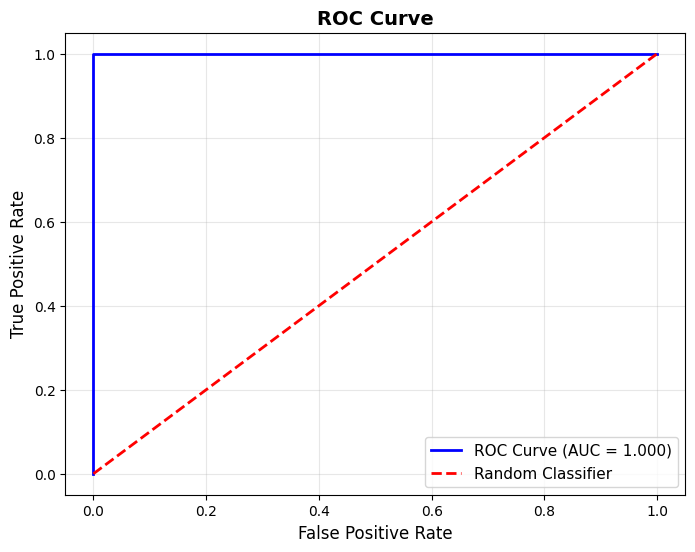

In [34]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Q6.5

In [35]:
print(f"\nArea Under Curve (AUC): {roc_auc:.3f}")


Area Under Curve (AUC): 1.000


Q6.6

A high AUC (close to 1.0) indicates excellent model performance with good separation between classes. A low AUC (close to 0.5) suggests the model performs no better than random guessing. Our AUC is 1.00 indicates that model performance is excellent

Q6.7

In [36]:
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

X = df3[['hours']]
y = df3['passed']

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X, y)

print("\nDecision Tree fitted with max_depth=2")
print(f"Training accuracy: {dt.score(X, y):.4f}")


Decision Tree fitted with max_depth=2
Training accuracy: 0.9000


Q6.8

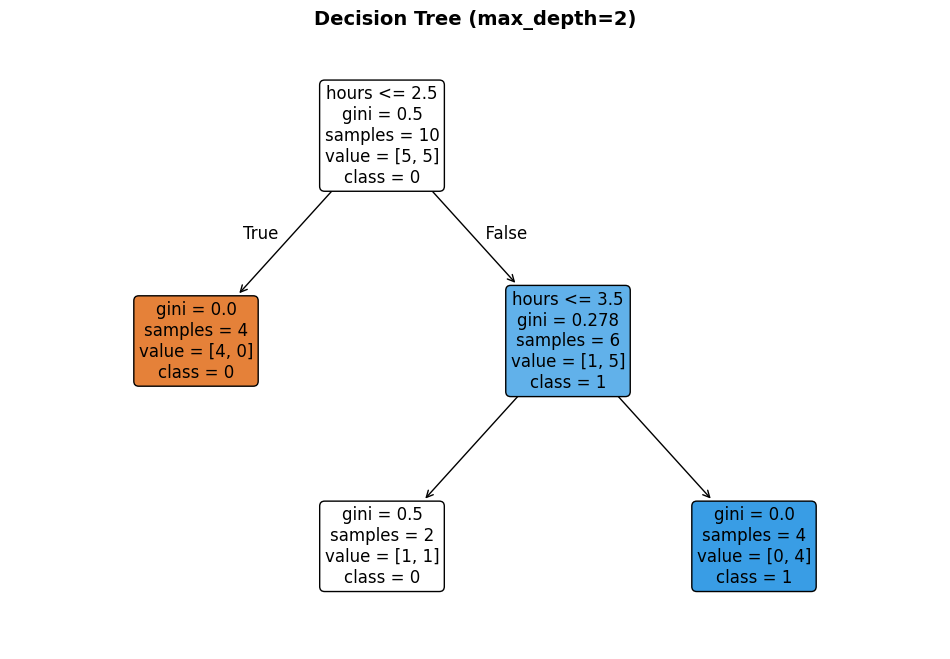

In [37]:
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=['hours'], class_names=['0', '1'],
          filled=True, rounded=True, fontsize=12)
plt.title('Decision Tree (max_depth=2)', fontsize=14, fontweight='bold')
plt.show()

Q6.9

The tree with max_depth=2 on a dataset of only 10 samples is actually well-constrained and unlikely to overfit severely. The limited depth prevents the model from memorizing individual data points. However, with such a small dataset, we cannot reliably assess generalization performance without cross-validation or a separate test set. The tree should generalize reasonably well given the depth constraint, but more data would be needed for confident evaluation.